Train Deep Neural Network on Dummy Data. 

Problem: Classify 3 classes.

1. Prepare Data

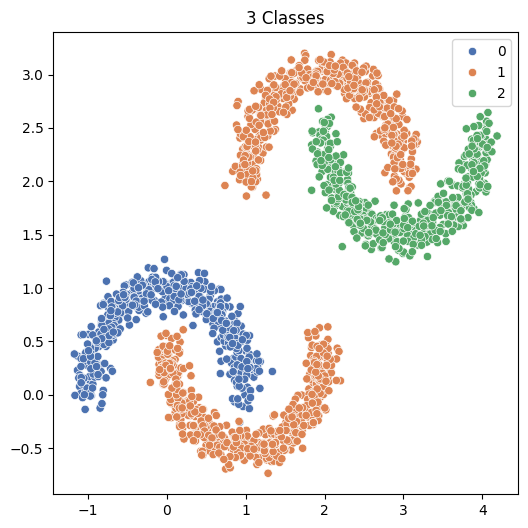

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import matplotlib
import seaborn as sns
np.random.seed(0)
X, y = sklearn.datasets.make_moons(1000, noise=0.10)
X2, y2 = sklearn.datasets.make_moons (1000, noise=0.10)
X2 = X2 + 2
y2 = y2 + 1
X = np.concatenate((X, X2))
Y = np.concatenate((y, y2))
matplotlib.rcParams['figure.figsize'] = (6.0, 6.0)
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="deep")
plt.title("3 Classes")
plt.show()

In [2]:
X[0:10]

array([[ 2.04271531,  0.51812416],
       [ 1.72033708, -0.13233804],
       [-0.26386729,  0.76382643],
       [-0.09803521,  0.18008157],
       [ 0.47847605, -0.39877762],
       [ 1.95457533,  0.3954806 ],
       [ 0.92760463,  0.33816128],
       [ 0.07354888,  0.97353212],
       [-0.5350633 ,  0.80666957],
       [ 0.68548842, -0.56261497]])

In [3]:
Y[0:10]

array([1, 1, 0, 1, 1, 1, 0, 0, 0, 1])

In [4]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

num_inputs = 2
batch_size = 128

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.astype(np.float32), Y, test_size=0.25, random_state=42)
X_train, X_test = torch.tensor(X_train), torch.tensor(X_test)
y_train, y_test = torch.tensor(y_train), torch.tensor(y_test)
train_dataset = TensorDataset (X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_data = DataLoader(train_dataset, batch_size, shuffle=True)
test_data = DataLoader(test_dataset, batch_size, shuffle=False)

#https://pytorch.org/docs/stable/data.html

2. Helper Functions

In [5]:
def evaluate_accuracy (data_iterator, net):
    labels = []
    predictions = []
    from sklearn.metrics import accuracy_score
    net = net.eval()
    with torch.no_grad():
        for i, (data, label) in enumerate(data_iterator):
            data = data.to(device).reshape((-1, num_inputs))
            label = label.to(device)
            output = net(data)
            pred = torch.argmax(output, axis=1)
            labels.extend(label.numpy())
            predictions.extend(pred.numpy())
    return accuracy_score(labels, predictions)

In [6]:
def pred_fn(X, net):
    dataset = TensorDataset(X)
    dataloader = DataLoader(dataset, batch_size, shuffle=False)
    predictions = []
    net = net.eval()
    with torch.no_grad():
        for i, (data,) in enumerate(dataloader):
            data = data.to(device).reshape((-1, num_inputs))
            output = net(data)
            pred = torch.argmax(output, axis=1)
            predictions.extend(pred.numpy())
    return np.array(predictions)

In [7]:
#If you don't fully understand this function don't worry, it just generates the contour plot below.
def plot_decision_boundary(net):
    #Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5 
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01
    #Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    meshed_array = np.c_[xx.ravel(), yy.ravel()]
    meshed_array = torch.tensor (meshed_array).type(torch.float32)
    #Predict the function value for the whole gid
    Z = pred_fn(meshed_array, net)
    z = Z.reshape(xx.shape)
    #Plot the contour and training examples
    plt.figure(num=None,figsize=(12, 12))
    plt.contourf(xx, yy, z, cmap = plt.cm.Spectral, alpha=0.8) 
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Spectral)
    plt.show()

In [8]:
def init_weights (module, std=None):
    if isinstance (module, nn.Sequential):
        for mod in module:
            init_weights (mod)
    else:
        if std is not None:
            pass
        elif hasattr(module, "weight") and len(module.weight.shape) >= 2 and not isinstance (module, nn.Embedding):
            fan_out, fan_in = module.weight.shape[:2]
            std = np.sqrt(1.0/ float(fan_in + fan_out))
        elif hasattr(module, "weight"):
            std = np.sqrt(1.0/module.weight.shape[-1])
        if hasattr(module, "weight"):
            nn.init.normal_(module.weight, std=std)
        if hasattr(module, "bias") and module.bias is not None:
            nn.init.constant_(module.bias, 0.0)

In [9]:
def build_network(num_inputs, num_outputs, num_layers, num_hidden, dropout=0.0, std=0.005 ) :
    layers = []
    layers.append(nn.Linear(num_inputs, num_hidden))
    layers.append(nn.ReLU())
    for _ in range(num_layers):
        layers.append(nn.Linear (num_hidden, num_hidden))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn. Dropout(dropout))

    layers.append(nn.Linear(num_hidden, num_outputs))
    net = nn.Sequential(*layers)
    init_weights(net, std=std)
    return net

In [10]:
def plot_loss(loss_sequence):
    plt.figure(num=None,figsize=(8, 6))
    plt.plot(loss_sequence)
    
    plt.grid(True, which="both")
    plt.xlabel('epoch',fontsize=14)
    plt.ylabel('average loss', fontsize=14)
    plt.show()

In [11]:
def train_net (net, epochs, optim='sgd', lr = 0.001 , batch_size = 128, momentum = 0.0, weight_decay=0.01):
    loss_sequence = []
    if optim =="sgd":
        from torch.optim import SGD
        optimizer = SGD(net.parameters(), lr=lr, momentum=momentum)
    elif optim == "adamw":
        from torch.optim import AdamW
        optimizer = AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
    elif optim == "adam":
        from torch.optim import Adam
        optimizer = Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    softmax_cross_entropy = nn.CrossEntropyLoss()
    moving_loss = None
    for e in range(epochs):
        net = net.train()
        cumulative_loss = 0
        for i, (data, label) in enumerate(train_data):
            data = data.to(device).reshape((-1, num_inputs))
            label = label.to(device)
            output = net(data)
            loss = softmax_cross_entropy(output, label)
            loss.backward()
            optimizer.step()
            loss_scalar = loss.item() / len(label)
            if moving_loss:
                moving_loss = 0.99 * moving_loss + 0.01 * loss_scalar
            else:
                moving_loss = loss_scalar
            cumulative_loss += loss_scalar
            loss_sequence.append(moving_loss)
        test_accuracy = evaluate_accuracy(test_data, net)
        train_accuracy = evaluate_accuracy(train_data, net)
        if e % (epochs // 10) == 0 or e == epochs - 1:
            print("Epoch: %s, Loss: %s, Train_acc: %s, Test_acc: %s" % (
                e, cumulative_loss/len(train_data), train_accuracy, test_accuracy))
    plot_loss(loss_sequence)

Initial Testing Accuracy =  0.492
Epoch: 0, Loss: 0.008856384033013297, Train_acc: 0.502, Test_acc: 0.494
Epoch: 20, Loss: 0.0041220799810590516, Train_acc: 0.78, Test_acc: 0.752
Epoch: 40, Loss: 0.002186506589287487, Train_acc: 0.9206666666666666, Test_acc: 0.896
Epoch: 60, Loss: 0.0021548183353118384, Train_acc: 0.9306666666666666, Test_acc: 0.918
Epoch: 80, Loss: 0.0013648427086899164, Train_acc: 0.9546666666666667, Test_acc: 0.932
Epoch: 100, Loss: 0.000806831477519523, Train_acc: 0.9933333333333333, Test_acc: 0.974
Epoch: 120, Loss: 0.00102539731576302, Train_acc: 0.974, Test_acc: 0.96
Epoch: 140, Loss: 0.0007290209477817015, Train_acc: 0.99, Test_acc: 0.984
Epoch: 160, Loss: 0.0004535675420885602, Train_acc: 0.9966666666666667, Test_acc: 0.998
Epoch: 180, Loss: 0.00016855217023966753, Train_acc: 0.9973333333333333, Test_acc: 0.996
Epoch: 199, Loss: 0.00016090758930771372, Train_acc: 0.9986666666666667, Test_acc: 0.996


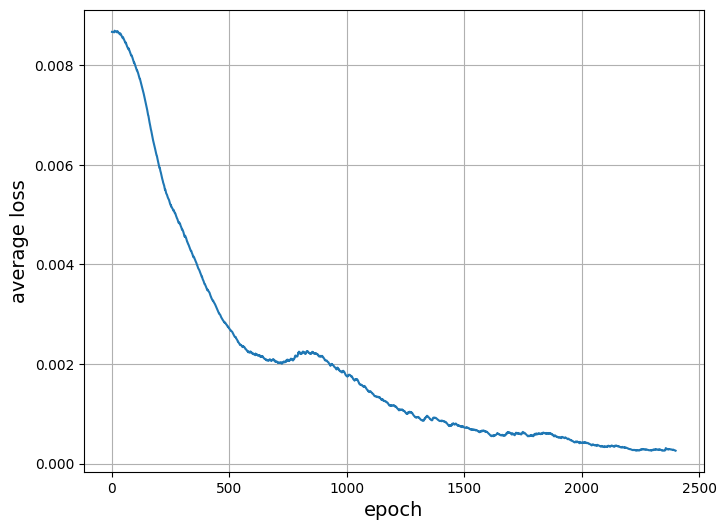

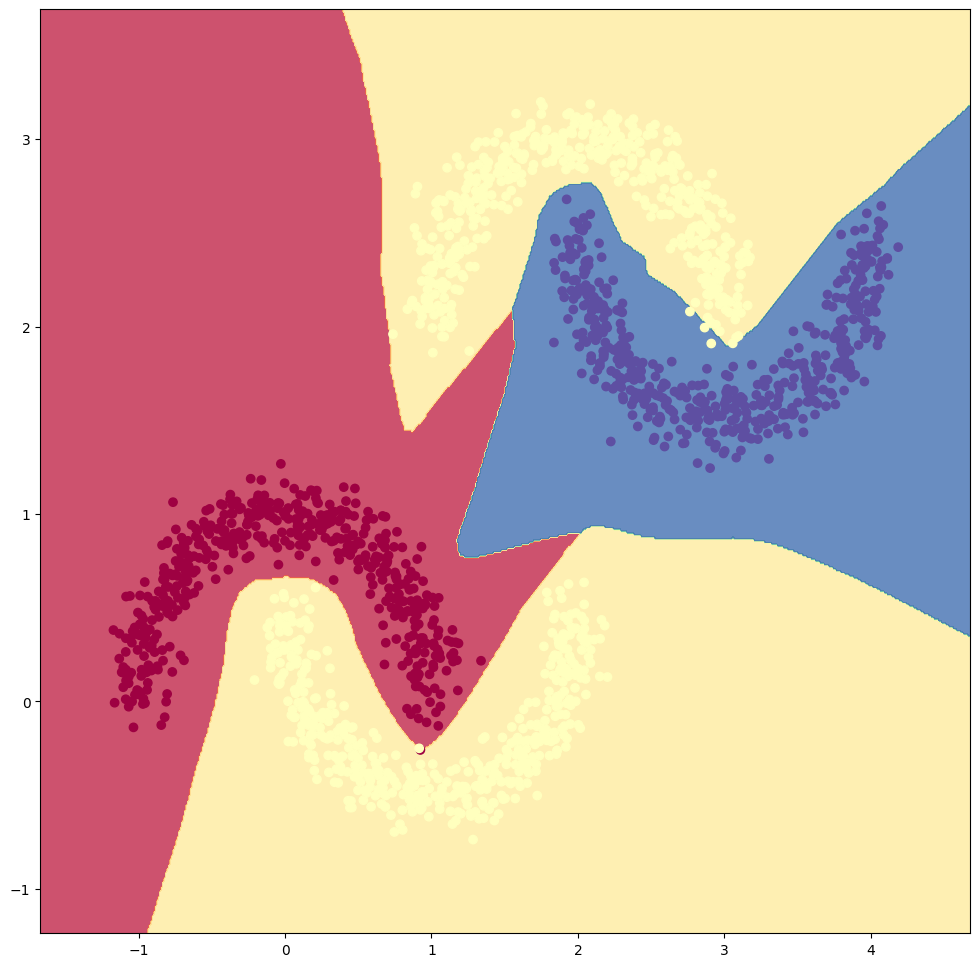

In [12]:
# num_inputs = 2
# num_outputs = 3
# num_layers = 1
# num_hidden = 32
# net = build_network(num_inputs, num_outputs, num_layers, num_hidden)
# print("Initial Testing Accuracy = ", evaluate_accuracy(test_data, net))
# train_net(net, epochs=25)
# plot_decision_boundary(net)

# num_inputs = 2
# num_outputs = 3
# num_layers = 1
# num_hidden = 32
# net = build_network(num_inputs, num_outputs, num_layers, num_hidden)
# print("Initial Testing Accuracy = ", evaluate_accuracy(test_data, net))
# train_net(net, epochs=100)
# plot_decision_boundary(net)

# num_inputs = 2
# num_outputs = 3
# num_layers = 4
# num_hidden = 128
# net = build_network(num_inputs, num_outputs, num_layers, num_hidden)
# print("Initial Testing Accuracy = ", evaluate_accuracy(test_data, net))
# train_net(net, epochs=100)
# plot_decision_boundary(net)

# num_inputs = 2
# num_outputs = 3
# num_layers = 4
# num_hidden = 128
# net = build_network(num_inputs, num_outputs, num_layers, num_hidden)
# print("Initial Testing Accuracy = ", evaluate_accuracy(test_data, net))
# train_net(net, epochs=100, optim="sgd", lr=0.001, momentum=0.2)
# plot_decision_boundary(net)

# num_inputs = 2
# num_outputs = 3
# num_layers = 4
# num_hidden = 128
# net = build_network(num_inputs, num_outputs, num_layers, num_hidden, std=0.02)
# print("Initial Testing Accuracy = ", evaluate_accuracy(test_data, net))
# train_net(net, epochs=100, optim="adamw", lr=0.00002, weight_decay=0.001)
# plot_decision_boundary(net)

num_inputs = 2
num_outputs = 3
num_layers = 1
num_hidden = 128
net = build_network(num_inputs, num_outputs, num_layers, num_hidden,dropout=0.1, std=0.02)
print("Initial Testing Accuracy = ", evaluate_accuracy(test_data, net))
train_net(net, epochs=200)
plot_decision_boundary(net)